In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import datetime
import json
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import wandb
from accelerate.commands.config.update import description
from transformers import (
    AutoModelForMaskedLM,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

def set_seed(seed=42) -> None:
    """Set all seeds to make results reproducible (deterministic mode).
    When seed is a false-y value or not supplied, disables deterministic mode."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(i).name)

# os.environ["MY_VARIABLE"] = "my_value"


NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000


## Load trained model from wandb

In [4]:
def load_model_from_wandb(model_path):
    run = wandb.init()
    artifact = run.use_artifact(model_path, type='model')
    artifact_dir = artifact.download()
    model = AutoModelForMaskedLM.from_pretrained(artifact_dir)
    return model, artifact_dir

def load_model_from_local(model_path):
    model = AutoModelForMaskedLM.from_pretrained(model_path)
    return model, model_path

def load_model(model_path, use_wandb=True):
    if use_wandb:
        return load_model_from_wandb(model_path)
    else:
        return load_model_from_local(model_path)
    
# checking if two hugging face models are same or not
model_from_wandb, model_from_wandb_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning-ej-classification/model-4o78kgin:v0")
model_from_local, model_from_local_path = load_model_from_local("/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/model_outputs/20241216_18-41-39/model")
# model_from_local, model_from_local_path = load_model_from_local("/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/model_outputs/20241211_15-10-59/model")


# Compare the state_dicts
are_models_identical = all(
    torch.equal(param1, param2) 
    for param1, param2 in zip(model_from_wandb.state_dict().values(), model_from_local.state_dict().values())
)

print(f"Are the models identical? {are_models_identical}")



wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sajil (nasa-impact). Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact model-4o78kgin:v0, 475.54MB. 3 files... 
wandb:   3 of 3 files downloaded.  
Done. 0:0:0.8
Some weights of RobertaForMaskedLM were not initialized from the model checkpoint at /nas/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/artifacts/model-4o78kgin:v0 and are newly initialized: ['lm_head.bias', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Are the models identical? False


## Load Data and split identiacally

In [5]:
from preprocess_data import preprocess_dataset
with open("config.json", "r") as file:
    config = json.load(file)

data_src = "local"
n_rows = None
lm_dataset, tokenizer, data_collator = preprocess_dataset(
        config.get("input"),
        data_src,
        n_rows,
    )

Map (num_proc=4):   0%|          | 0/96992 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/12124 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/12124 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/96992 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/12124 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/12124 [00:00<?, ? examples/s]

## Make Predictions on train and test data

In [12]:
from utils import generate_inference

test_inference_df = generate_inference(
        lm_dataset["test"],
        tokenizer,
        model_from_local_path,
        top_k=config.get("output").get("inference").get("top_k"),
        n_predictions=None
)

train_inference_df = generate_inference(
        lm_dataset["train"],
        tokenizer,
        model_from_local_path,
        top_k=config.get("output").get("inference").get("top_k"),
        n_predictions=None
)


Map:   0%|          | 0/28416 [00:00<?, ? examples/s]

Device set to use cuda:0


Map:   0%|          | 0/214832 [00:00<?, ? examples/s]

Device set to use cuda:0


In [13]:
train_inference_df.to_parquet("tmp/inferences/train_inference.parquet")
test_inference_df.to_parquet("tmp/inferences/test_inference.parquet")

In [14]:
# # Find the document with the maximum tokens without modifying the dataset
# max_tokens_document = max(lm_dataset["validation"], key=lambda x: len(x['input_ids']))

# # Print details
# print(f"Number of tokens: {len(max_tokens_document['input_ids'])}")
# print(f"Document: {max_tokens_document}")

# decoded_text = tokenizer.decode(max_tokens_document['input_ids'], skip_special_tokens=True)
# print(decoded_text)

Number of tokens: 500
Document: {'input_ids': [0, 29429, 14259, 149, 18845, 434, 428, 918, 5402, 149, 228, 1703, 223, 14259, 2595, 149, 1165, 149, 2298, 2055, 31811, 883, 35, 149, 2856, 59, 149, 2001, 6620, 149, 3817, 322, 149, 30981, 1979, 46931, 1849, 149, 3132, 149, 40266, 873, 149, 37199, 149, 29783, 25182, 149, 1285, 7802, 149, 13237, 30934, 149, 14080, 46931, 1849, 149, 37199, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 2263, 1930, 149, 13990, 5378, 149, 8246, 567, 149, 6339, 11605, 149, 29783, 25182, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 2263, 1930, 149, 8246, 567, 149, 6339, 11605, 149, 1285, 7802, 149, 3132, 149, 30981, 1979, 46931, 1849, 149, 3566, 7245, 313, 149, 3566, 15371, 149, 9712, 1441, 149, 3400, 149, 2298, 666, 21081, 35, 149, 13793, 18042, 149, 9712, 4031, 149, 25182, 149, 14761, 4970, 24817, 149, 20879, 215, 12532, 149, 13990, 5378, 149, 3104, 305, 2076, 149, 3173, 17, 26714, 8207, 149, 4691, 149, 5478, 206, 4691, 149, 40266, 873, 149, 14080, 46931, 184

In [15]:
test_inference_df.head()

,sequence,target,top1,top2,top3
0,skip to main content missions search all na...,missions,"{'score': 1.0, 'token_str': ' missions', 'toke...","{'score': 0.0, 'token_str': ' mission', 'token...","{'score': 0.0, 'token_str': ' nasa', 'token': ..."
1,"pia15670: oppia region, three ways target na...",the,"{'score': 0.9943, 'token_str': ' the', 'token'...","{'score': 0.0039, 'token_str': ' relative', 't...","{'score': 0.0006, 'token_str': ' surface', 'to..."
2,atmosphere heat human presence land life ...,k,"{'score': 0.9969, 'token_str': ' k', 'token': ...","{'score': 0.0012, 'token_str': ' km', 'token':...","{'score': 0.0003, 'token_str': 'k', 'token': 53}"
3,department described the winter of 2007-2008 ...,dust,"{'score': 0.9999, 'token_str': ' dust', 'token...","{'score': 0.0, 'token_str': 'dust', 'token': 4...","{'score': 0.0, 'token_str': ' ', 'token': 149}"
4,skip to content nasa power | docs nasa powe...,power,"{'score': 0.162, 'token_str': ' zone', 'token'...","{'score': 0.1256, 'token_str': ' data', 'token...","{'score': 0.0516, 'token_str': ' area', 'token..."


# Compute distribution of probablity for train and test for top1,2,3

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_score_distribution(inference_df, dataset_split):
    _inference_df = inference_df.copy()
    top_scores_str = [c for c in inference_df.columns if "top" in c]

    # Safely extract scores
    for col in top_scores_str:
        _inference_df[col] = inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)

    # Melt the DataFrame for plotting
    _inference_df = _inference_df.melt(
        value_vars=top_scores_str,
        var_name='Category',
        value_name='Scores'
    )
    _inference_df = _inference_df.dropna(subset=['Scores'])

    # Check if data is sufficient for plotting
    if _inference_df.empty:
        print("No valid data available for plotting.")
        return

    # Plot KDE
    plot = sns.kdeplot(data=_inference_df, x='Scores', hue='Category', fill=True)

    # Ensure legend is displayed
    plt.title(f'{dataset_split} Distribution of Scores for {", ".join(top_scores_str)}')
    plt.xlabel('Scores')
    plt.ylabel('Density')

    # Force legend display
    handles, labels = plot.get_legend_handles_labels()
    if handles and labels:
        plt.legend(handles=handles, labels=labels, title='Category')
    else:
        print("Warning: Legend could not be generated. Please verify 'Category' column values.")
    
    plt.show()


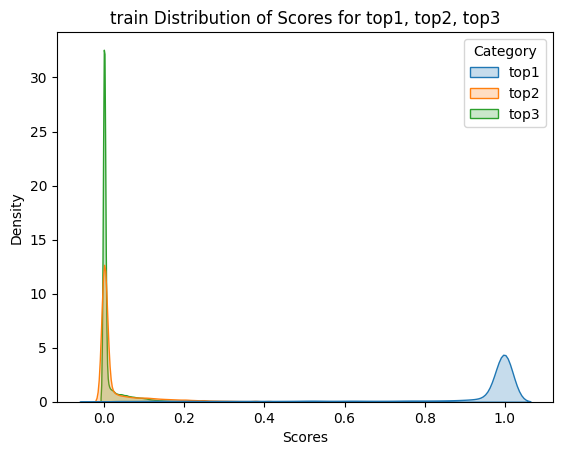

In [17]:
plot_score_distribution(train_inference_df, "train")

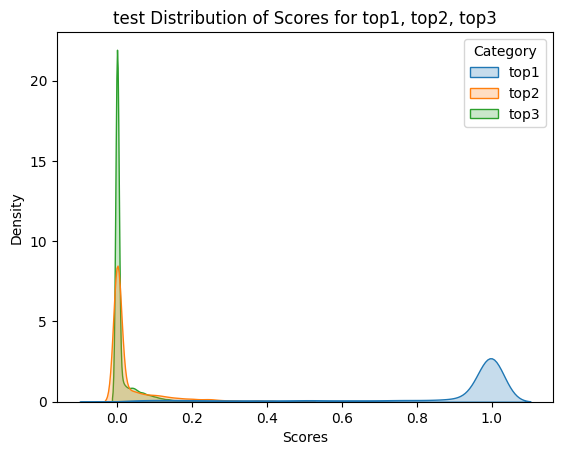

In [18]:
plot_score_distribution(test_inference_df, "test")

## Compare test-train distributions of scores

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_dataset_score_distribution(train_inference_df, test_inference_df):
    """
    Compare top1, top2, and top3 scores from train and test datasets across multiple subplots.
    
    Args:
        train_inference_df (pd.DataFrame): Inference dataframe for training data.
        test_inference_df (pd.DataFrame): Inference dataframe for testing data.
    """
    top_n = [c for c in train_inference_df.columns if "top" in c]
    
    # Extract top1, top2, top3 scores
    train_scores = {
        col: train_inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)
        for col in top_n
    }
    test_scores = {
        col: test_inference_df[col].apply(lambda x: x.get('score', 0.0) if isinstance(x, dict) else 0.0)
        for col in top_n
    }
    
    # Create subplots
    fig, axs = plt.subplots(len(top_n), 1, figsize=(6, 4 * len(top_n)))
    
    for i, col in enumerate(top_n):
        # Create a comparison DataFrame for each top score
        comparison_df = pd.DataFrame({
            'Train': train_scores[col],
            'Test': test_scores[col]
        }).melt(var_name='Dataset', value_name='Scores')
        
        # KDE Plot for each top score
        sns.kdeplot(data=comparison_df, x='Scores', hue='Dataset', fill=True, ax=axs[i])
        axs[i].set_title(f'Distribution of {col} Scores (Train vs Test)')
        axs[i].set_xlabel('Scores')
        axs[i].set_ylabel('Density')
        
        # Ensure each subplot has its own legend
        handles, labels = axs[i].get_legend_handles_labels()
        if handles and labels:
            axs[i].legend(handles=handles, labels=labels, title='Dataset')
        else:
            print(f"Warning: Legend could not be generated for subplot {i + 1}.")
    
    # Adjust layout
    plt.tight_layout()
    plt.show()


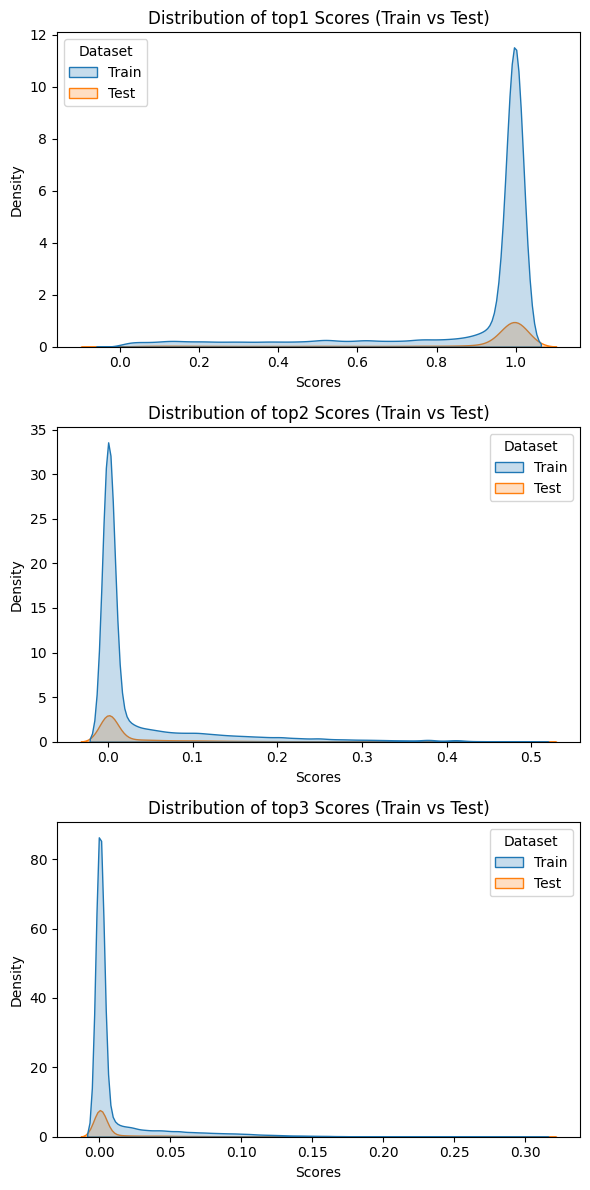

In [20]:
plot_dataset_score_distribution(train_inference_df, test_inference_df)

## Generate accuracy for top 1, top2, top3 predictions

In [21]:
def get_accuracy(inference_df):
    _inference_df = inference_df.copy()
    top_n = [c for c in _inference_df.columns if "top" in c]

    _inference_df['predictions'] = _inference_df.apply(lambda row: [row[col].get('token_str') for col in top_n], axis=1)

    for i, top_i in enumerate(top_n):
        _inference_df[f'{top_i}_correct'] = _inference_df.apply(lambda row: int(row['target'] in row['predictions'][:i+1]), axis=1)

    accuracy = {top_i: _inference_df[f'{top_i}_correct'].mean() for top_i in top_n}

    return accuracy

train_accuracy = get_accuracy(train_inference_df)
test_accuracy = get_accuracy(test_inference_df)

In [22]:
print("Train Accuracy:")
print(train_accuracy)
print()
print("Test Accuracy:")
print(test_accuracy)

Train Accuracy:
{'top1': np.float64(0.8329764653310494), 'top2': np.float64(0.8894810828926789), 'top3': np.float64(0.9070995010054368)}

Test Accuracy:
{'top1': np.float64(0.8146818693693694), 'top2': np.float64(0.8715160472972973), 'top3': np.float64(0.8892173423423423)}
